In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
df = pd.read_csv(r"C:\Users\NARENDRA\Downloads\Decision Tree  - Assignment -4\Decision Tree  - Assignment -4\iphone_purchase_records.csv")

df.head()

,Gender,Age,Salary,Purchase Iphone
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [4]:
df.shape

(400, 4)

In [5]:
df.info

<bound method DataFrame.info of      Gender  Age  Salary  Purchase Iphone
0      Male   19   19000                0
1      Male   35   20000                0
2    Female   26   43000                0
3    Female   27   57000                0
4      Male   19   76000                0
..      ...  ...     ...              ...
395  Female   46   41000                1
396    Male   51   23000                1
397  Female   50   20000                1
398    Male   36   33000                0
399  Female   49   36000                1

[400 rows x 4 columns]>

In [6]:
df.isnull().sum()

Gender             0
Age                0
Salary             0
Purchase Iphone    0
dtype: int64

In [7]:
df.describe()

,Age,Salary,Purchase Iphone
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


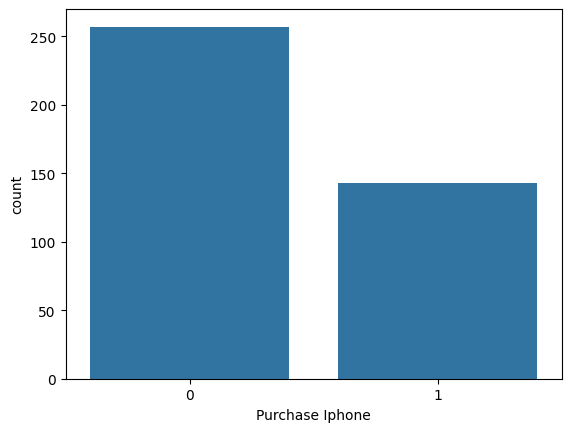

In [8]:
sns.countplot(data=df, x="Purchase Iphone")

plt.show()

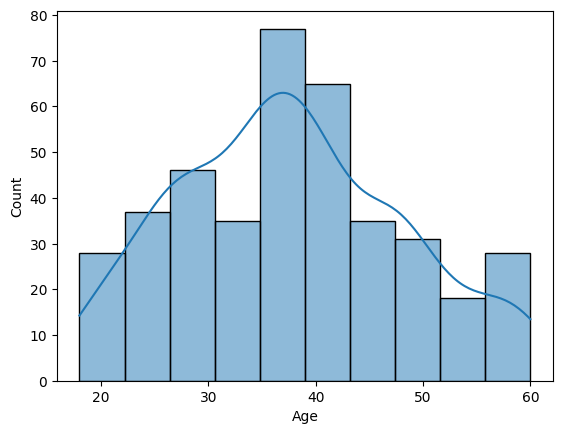

In [9]:
sns.histplot(df["Age"], kde=True)

plt.show()

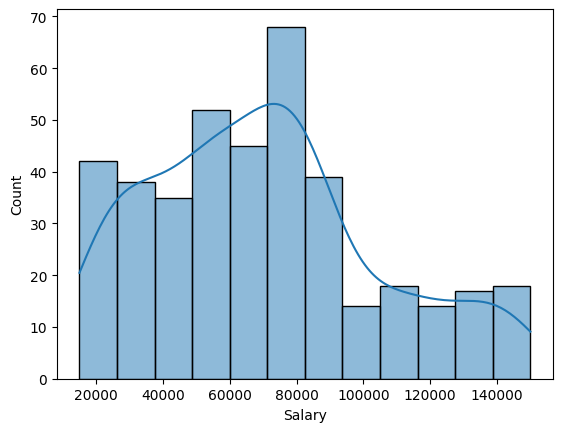

In [10]:
sns.histplot(df["Salary"], kde=True)

plt.show()

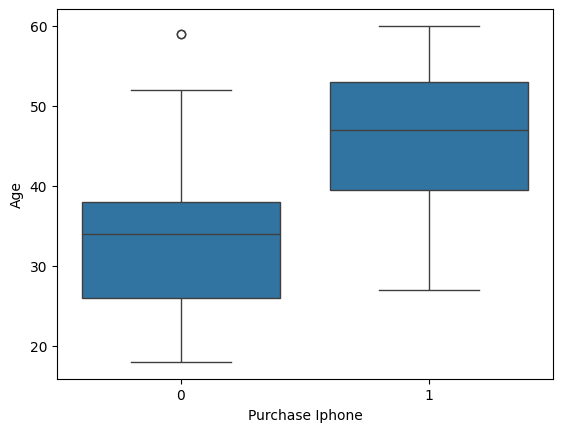

In [11]:
sns.boxplot(data=df, x="Purchase Iphone", y="Age")

plt.show()

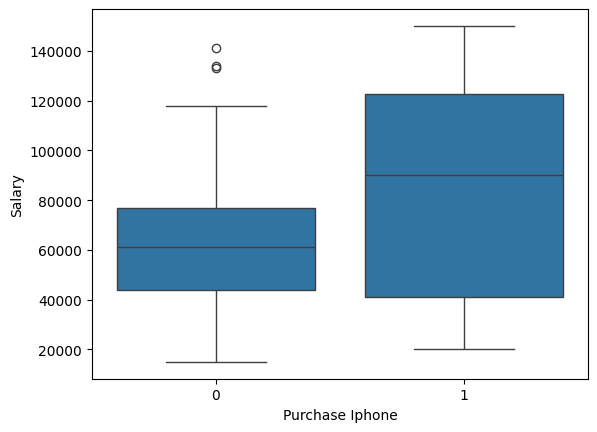

In [12]:
sns.boxplot(data=df, x="Purchase Iphone", y="Salary")

plt.show()

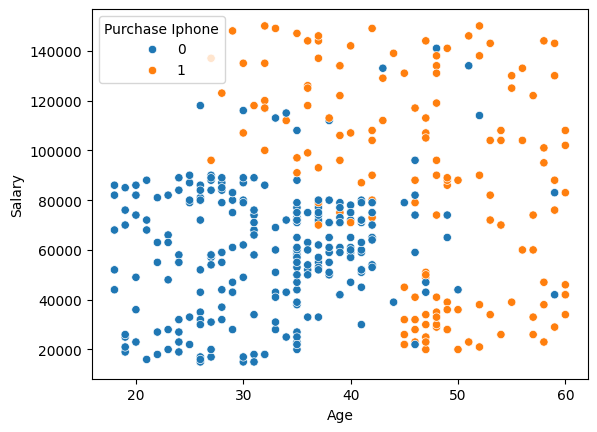

In [13]:
sns.scatterplot(
    data=df,
    x="Age",
    y="Salary",
    hue="Purchase Iphone"
)

plt.show()

In [14]:
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

df.head()

,Gender,Age,Salary,Purchase Iphone
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0


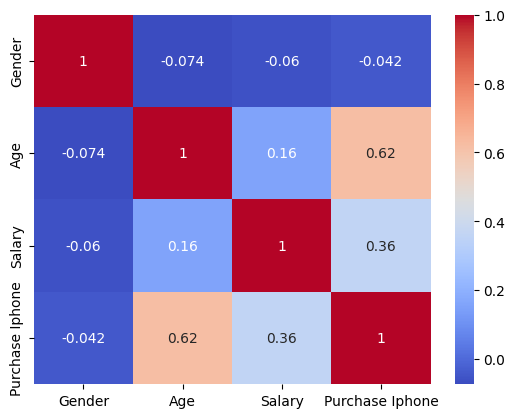

In [15]:
corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [16]:
X = df[["Gender", "Age", "Salary"]]

y = df["Purchase Iphone"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
y_pred = model.predict(X_test)

In [20]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy =", accuracy)

Accuracy = 0.9125


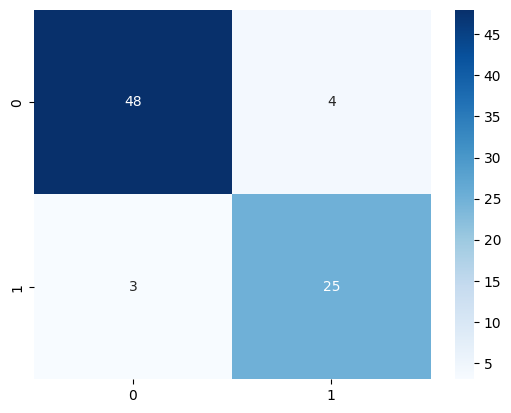

In [21]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.show()

In [22]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.92      0.93        52
           1       0.86      0.89      0.88        28

    accuracy                           0.91        80
   macro avg       0.90      0.91      0.90        80
weighted avg       0.91      0.91      0.91        80



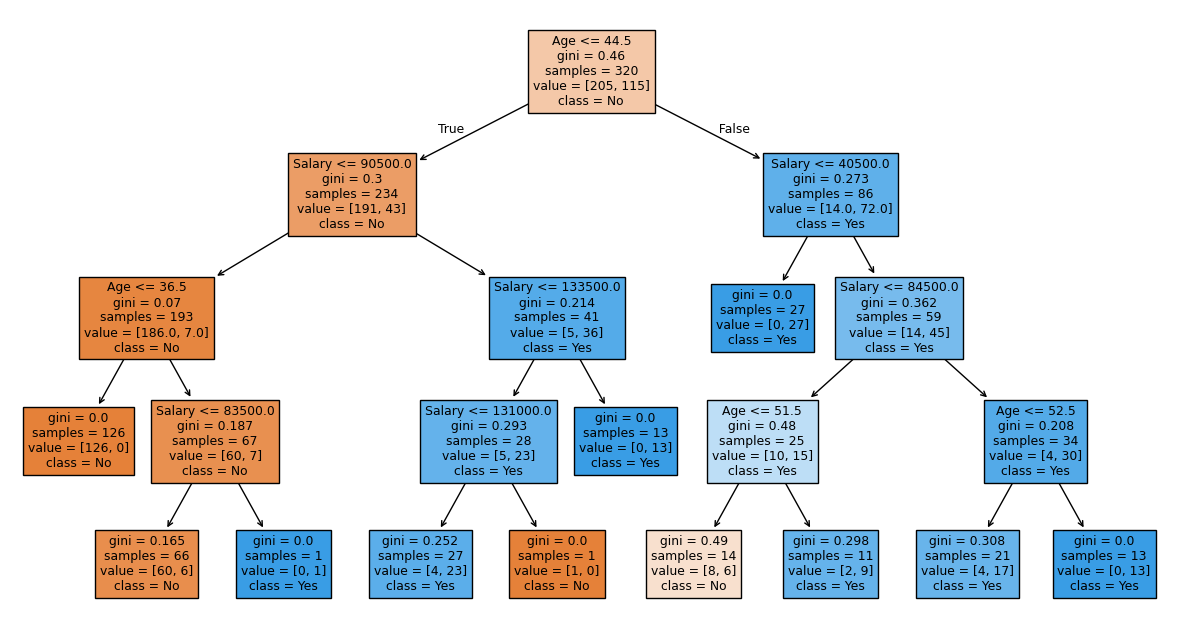

In [23]:
plt.figure(figsize=(15,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True
)

plt.show()

In [24]:
sample = pd.DataFrame(
    [[1, 35, 50000]],
    columns=["Gender", "Age", "Salary"]
)

prediction = model.predict(sample)

print(prediction)

[0]


In [25]:
if prediction[0] == 1:
    print("Customer likely to purchase iPhone")
else:
    print("Customer not likely to purchase iPhone")

Customer not likely to purchase iPhone


In [26]:
print("""
Conclusion

EDA was performed on Gender, Age and Salary.

Age and Salary showed strong influence on purchase behaviour.

Decision Tree Classifier was trained successfully.

The model was evaluated using Accuracy, Confusion Matrix and Classification Report.

Inference was performed on a new customer record.

The model can predict whether a customer is likely to purchase an iPhone.
""")


Conclusion

EDA was performed on Gender, Age and Salary.

Age and Salary showed strong influence on purchase behaviour.

Decision Tree Classifier was trained successfully.

The model was evaluated using Accuracy, Confusion Matrix and Classification Report.

Inference was performed on a new customer record.

The model can predict whether a customer is likely to purchase an iPhone.

